# 3.1 The Problem with Modeling Long Sequences

The problem with pre-LLM acrhitectures that do not include attention mechanisms is they are not aware of the structure of the tokens. For example, grammar often changes the order of words in a translation task. If we wanted to translate the German phrase "Kanns du mir helfen disen Satz zu uebersetzen" into English word by word it would result in "Can you me help this sentence to transate". Certain words require access to words that appeared earlier or later in the original sentence to shuffle them around to get the actual translation of "Can you help me to translate this sentence".

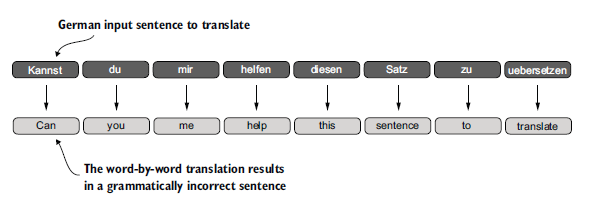

Before transformers - RNNs (recurrent neural networks) were used primarily for these kinds of translation texts. It essentially took the input tokens, converted them into a "hidden state", passed these "hidden states" to the decoder, and it would translate the word by referencing the "hidden state". The big limitation here is that the RNN cannot access earlier hidden states from the encoder during the decoder phase. This can lead to a loss of context - especially in complex sentences where dependencies might span long distances.

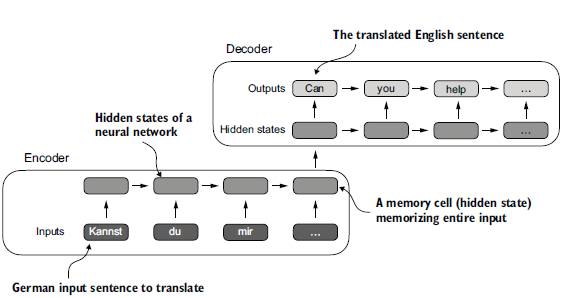

It's not essential to understand RNNs to build an LLM. Just know that the shortcomings of RNNs motivated the design of attention mechanisms.

# 3.2 Capturing data dependencies with attention mechanisms

As discussed previously, RNNs don't work well for longer texts since they don't have access to the previous words in the input. Researched developed the "Bahdanau attention" mechanism so that the encoder-decoder RNN's decoder can access different parts of the input sequence at each step.

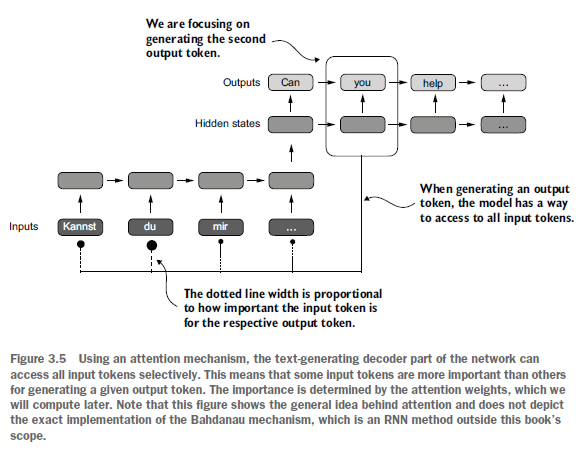

In the figure above - you can see that in the decoder steps have access to all of the original inputs, and the importance of each one is defined by it's attention weights which we will compute later. This just gives a general idea of how the attention mechanism works, and it's not an exact representation.

Three years later researchers found that RNN architecture is not neccesary for building NLPs and proposed the transformer architecture inlcuding a "self-attention" mechanism. This mechanism allows each position in the input sequence to consider the relevancy of all other positions in the same sequence. Essentially - how important are the other positions to this position?

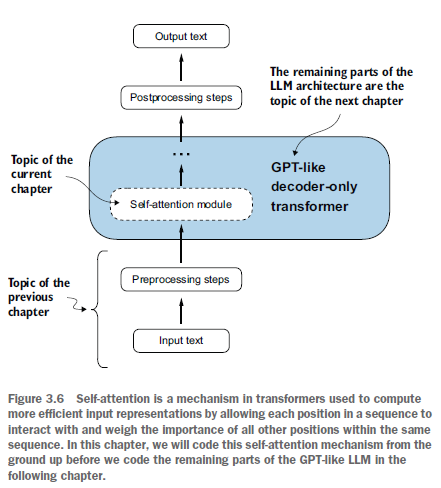

# 3.3 Attending to different parts of the input with self-attention

Self-attention is the cornerstone for every LLM based on the transformer architecture. This topic is very difficult to understand, but grasping the fundamentals is crucuial, and one of the toughests aspects of LLM implementation.

The "self" in self attention refers to the mechanism's ability to compute attention weights by relating the different positions in a single input sequence. It learns the relationships and depdencies between various parts of the input itself - like words in a sentence or pixels in an image. In contrast to traditional attention mechanisms - which focuses on the relationships of two entirely different sequences.

## 3.3.1 A simple self-attention mechanism without trainable weights

This is a simplified variant of self-attention, ignoring trainable weights for now.

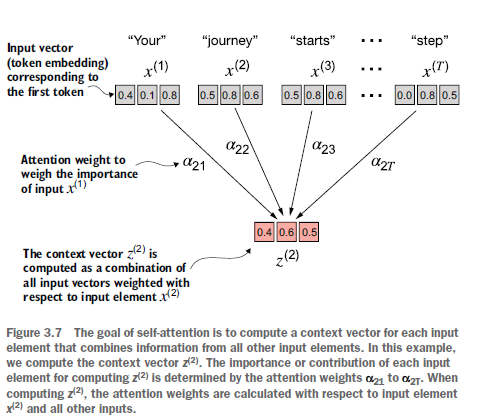

The input sequence is denoted by x, and have the input vector (token embedding). In self-attention the goal is to calculate a "context vector" for each element in the input sequence. This illustration focuses on the context vector of element 2 in the sequence. The context vector is an embedding that contains information about x(2) an all of the other input elements in the sequence (x(1) to x(T)). In between we see the attention weights - these are the weights used to weight the importance of the other inputs. In the illustration a21 is the weight that represents the importance of input 1 to input 2.

We end up with a context vector z(2) for the input x(2) which is a combination of all input vectors weighted with respect to the input element x(2). The purpose of this is to create enriched represntations of each element, by incorporating the information from all other elements in the sequence.

Below is a representation of how we calculate the attention scores between x(2) and the other inputs

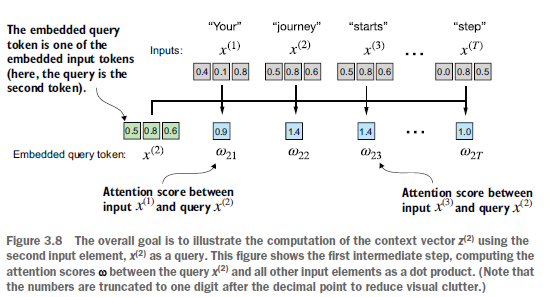

The embedded query token is one of the input tokens (in this case the second). This illustrates the computation of attention scores denoted by the a(21), a(22), a(23), ..., a(2T). These are computed by taking the dot product of the query x(2) with every other input token which results in one score. The dot product essentially measures the similarity because it quanitifies how closely two vectors are aligned - a higher dot product indicates greater alignment. In the context of self-attention the dot product determines to what extent each element in a sequence "attends to" another element.

Next we normalize the attention weights so they add up to one (for training stability). Finally - we multiply each input vector by the attention weights, and sum them resulting in our final context vector.

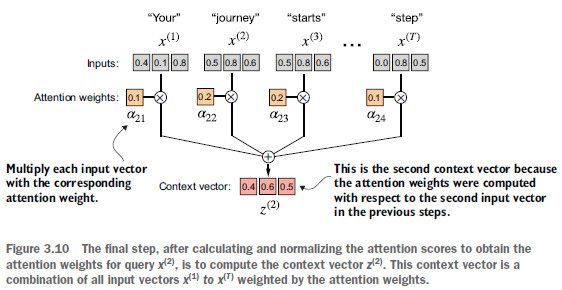

## 3.3.3 Computing attention weights for all input tokens

We can extend the previous computation to calculate attention weights and context vectors for all inputs.

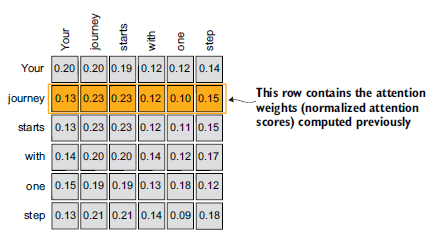

These are the sequential steps we take to calculate every context vector:

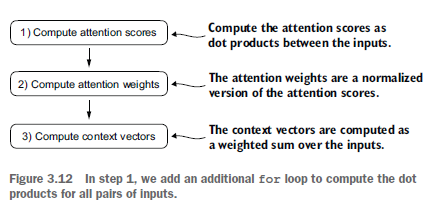

Finally we can use matrix multiplication of the attention weights and inputs to get our context vectors

# 3.4 Implementing self-attention with trainable weights

The figure below shows how the self-attention mechanism fits into the broader context of implementing an LLM

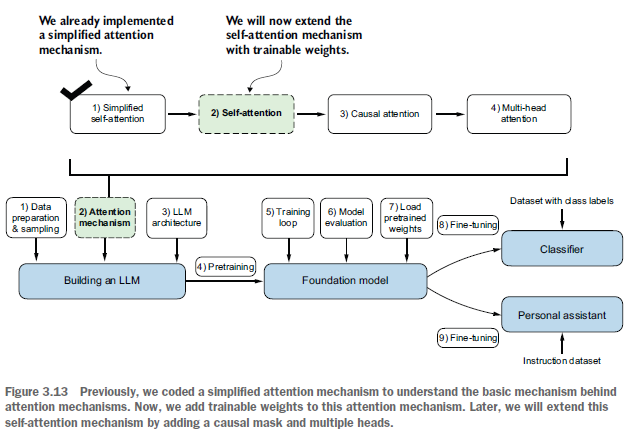

This self-attention with trainable weights builds on the previous concepts. The most notable difference is the introduction of weight matrices that are updated during model training - this is crucial for the model to produce "good" context vectors.

## 3.4.1 Computing the attnetion weights step by step

We introduce three trainable weight matrices enoted by W(q), W(k), and W(v). These are used to project the embedded input tokens into query, key, and value vectors as shown below.

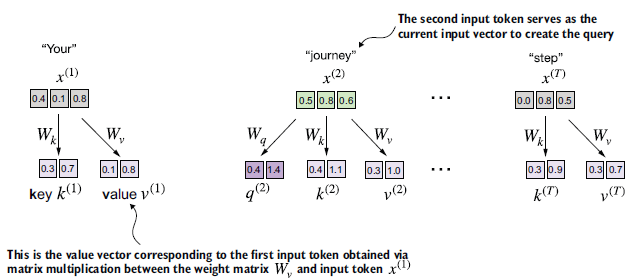